## Step 1: Import Libraries and Load Configuration

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from motion_detection import MotionDetector, MotionDetectionConfig
import yaml

# Set up matplotlib for better visualization
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['image.cmap'] = 'gray'

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Step 2: Load Configuration

In [36]:
# Load configuration from config.yaml
with open('config.yaml', 'r') as f:
    config_dict = yaml.safe_load(f)

# Extract motion detection config
motion_config = MotionDetectionConfig.from_dict(config_dict.get('motion_detection', {}))

print("Motion Detection Configuration:")
print(f"  Alpha Background: {motion_config.alpha_background}")
print(f"  Alpha Threshold: {motion_config.alpha_threshold}")
print(f"  Initial Threshold: {motion_config.initial_threshold}")
print(f"  Shadow Ratio Range: [{motion_config.shadow_ratio_min}, {motion_config.shadow_ratio_max}]")
print(f"  Motion Threshold: {motion_config.motion_threshold}")
print(f"  Morphology Kernel Size: {motion_config.morpho_kernel_size}")

Motion Detection Configuration:
  Alpha Background: 0.05
  Alpha Threshold: 0.03
  Initial Threshold: 30.0
  Shadow Ratio Range: [0.18, 0.95]
  Motion Threshold: 30
  Morphology Kernel Size: 7


## Step 3: Initialize Motion Detector

In [37]:
# Create motion detector instance
detector = MotionDetector(config=motion_config)

print("✓ Motion detector initialized")

✓ Motion detector initialized


## Step 4: Load Video

In [38]:
# Specify video path (update this to your video file)
video_path = 'datasets/test2.mp4'  # Change to your video path

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("❌ Error: Could not open video file")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"✓ Video loaded successfully")
    print(f"  Resolution: {width}x{height}")
    print(f"  FPS: {fps}")
    print(f"  Total Frames: {frame_count}")
    print(f"  Duration: {frame_count/fps:.2f} seconds")

✓ Video loaded successfully
  Resolution: 1280x720
  FPS: 29.97002997002997
  Total Frames: 62730
  Duration: 2093.09 seconds


## Step 5: Read Initial Frames

✓ Initial frames loaded


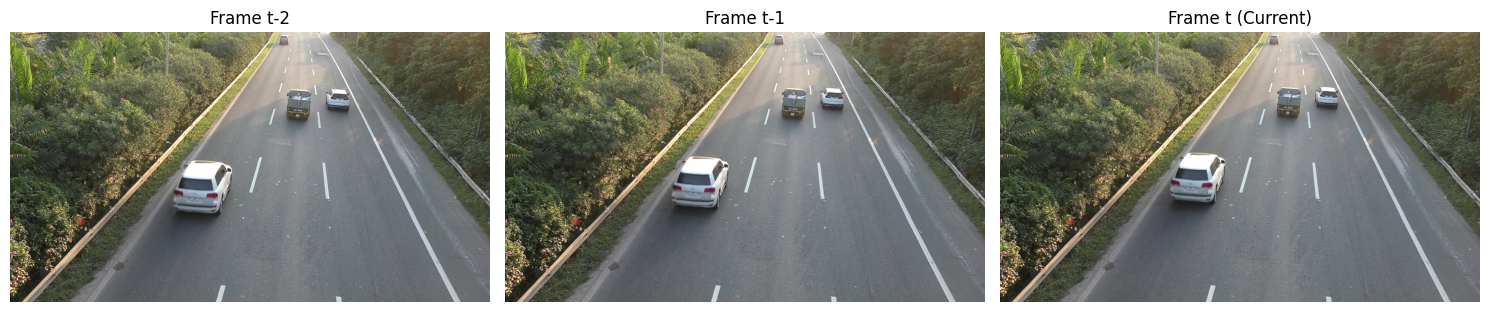

In [39]:
# Read first three frames
ret1, frame1 = cap.read()
ret2, frame2 = cap.read()
ret3, frame3 = cap.read()

if not (ret1 and ret2 and ret3):
    print("❌ Error: Could not read initial frames")
else:
    print("✓ Initial frames loaded")
    
    # Visualize the three frames
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Frame t-2')
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Frame t-1')
    axes[1].axis('off')
    
    axes[2].imshow(cv2.cvtColor(frame3, cv2.COLOR_BGR2RGB))
    axes[2].set_title('Frame t (Current)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

## Step 6: Initialize Background Model

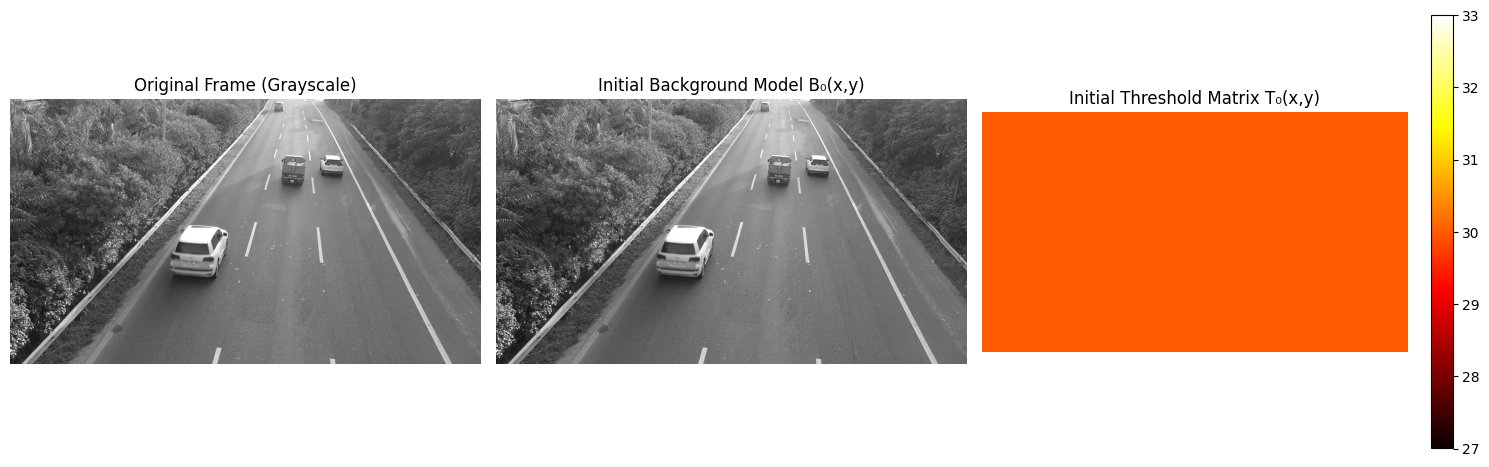

Background initialized with shape: (720, 1280)
Threshold range: [30.00, 30.00]


In [40]:
# Initialize detector with first frame
_ = detector.compute_foreground_mask(frame1)

# Visualize initial background and threshold matrix
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
axes[0].imshow(gray1, cmap='gray')
axes[0].set_title('Original Frame (Grayscale)')
axes[0].axis('off')

axes[1].imshow(detector.background, cmap='gray')
axes[1].set_title('Initial Background Model B₀(x,y)')
axes[1].axis('off')

im = axes[2].imshow(detector.threshold_matrix, cmap='hot')
axes[2].set_title('Initial Threshold Matrix T₀(x,y)')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

print(f"Background initialized with shape: {detector.background.shape}")
print(f"Threshold range: [{detector.threshold_matrix.min():.2f}, {detector.threshold_matrix.max():.2f}]")

## Step 7: Process Frame and Show Intermediate Steps

In [41]:
# Process frame 3 and capture intermediate results
curr = detector._to_gray(frame3)
prev = detector._to_gray(frame2)
prev2 = detector._to_gray(frame1)

# Step 1: Three-frame differencing
motion_mask = detector._three_frame_diff(curr, prev, prev2)

# Step 2: Background subtraction
bg_fg = detector._background_subtraction(curr)

# Step 3: Masked background subtraction
masked_bg = cv2.bitwise_and(bg_fg, motion_mask)

# Step 4: Two-frame differencing
two_frame = detector._two_frame_diff(curr, prev)

# Step 5: Add spatial support
support_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
motion_support = cv2.dilate(motion_mask, support_kernel, iterations=2)
two_frame_supported = cv2.bitwise_and(two_frame, motion_support)

# Step 6: Merge
fg_before_shadow = masked_bg.copy()
fg_before_shadow[two_frame_supported > 0] = 255

# Step 7: Shadow removal
fg_after_shadow = detector._remove_shadows(curr, fg_before_shadow)

# Step 8: Morphological cleanup
final_fg = detector._cleanup(fg_after_shadow)

print("✓ All intermediate steps computed")

✓ All intermediate steps computed


## Step 8: Visualize All Pipeline Steps

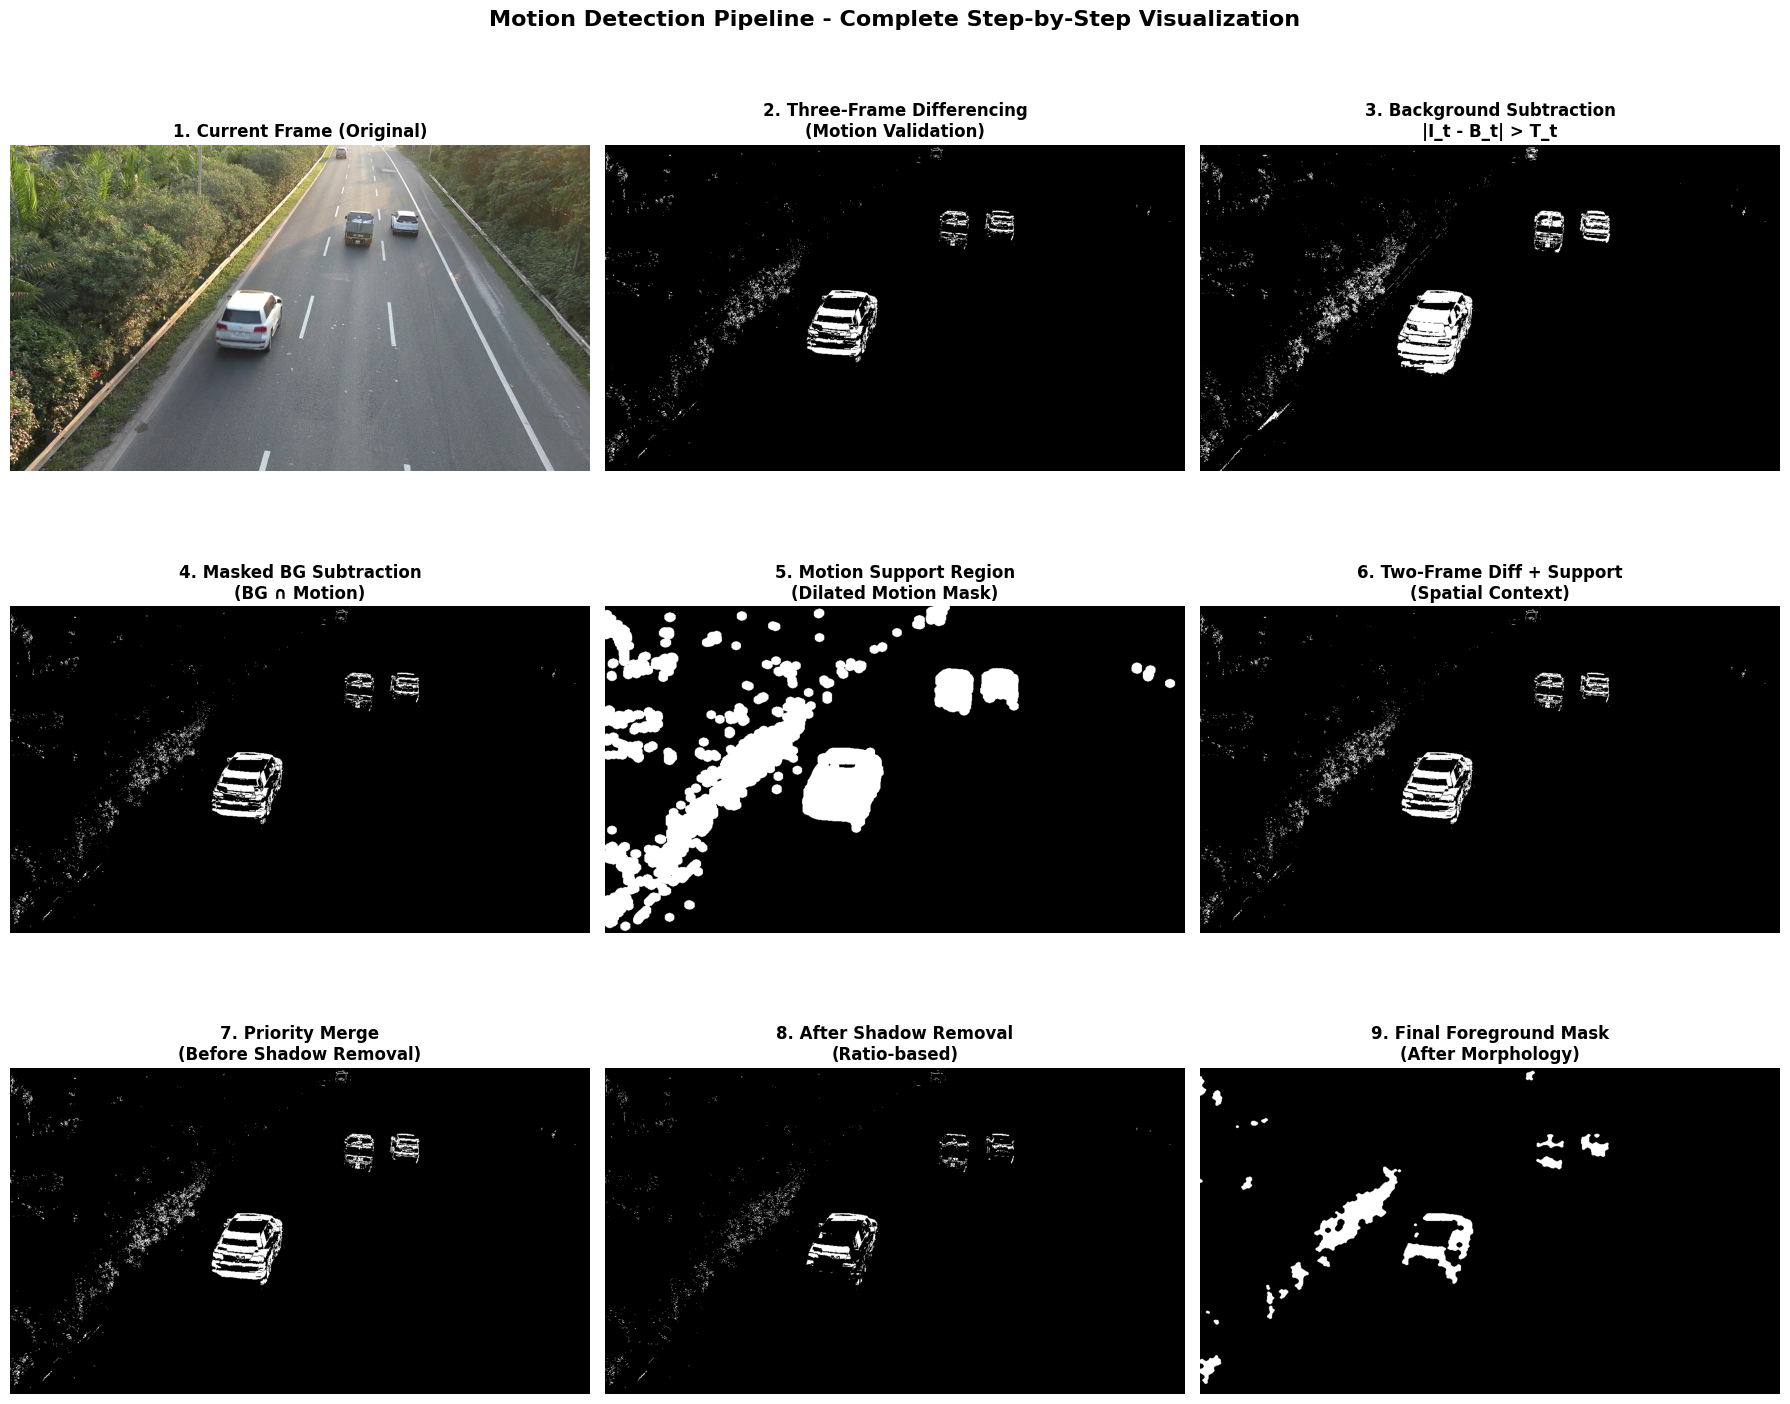

In [42]:
# Create comprehensive visualization
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Row 1: Input and basic operations
axes[0, 0].imshow(cv2.cvtColor(frame3, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('1. Current Frame (Original)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(motion_mask, cmap='gray')
axes[0, 1].set_title('2. Three-Frame Differencing\n(Motion Validation)', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(bg_fg, cmap='gray')
axes[0, 2].set_title('3. Background Subtraction\n|I_t - B_t| > T_t', fontsize=12, fontweight='bold')
axes[0, 2].axis('off')

# Row 2: Masking and two-frame operations
axes[1, 0].imshow(masked_bg, cmap='gray')
axes[1, 0].set_title('4. Masked BG Subtraction\n(BG ∩ Motion)', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(motion_support, cmap='gray')
axes[1, 1].set_title('5. Motion Support Region\n(Dilated Motion Mask)', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(two_frame_supported, cmap='gray')
axes[1, 2].set_title('6. Two-Frame Diff + Support\n(Spatial Context)', fontsize=12, fontweight='bold')
axes[1, 2].axis('off')

# Row 3: Final stages
axes[2, 0].imshow(fg_before_shadow, cmap='gray')
axes[2, 0].set_title('7. Priority Merge\n(Before Shadow Removal)', fontsize=12, fontweight='bold')
axes[2, 0].axis('off')

axes[2, 1].imshow(fg_after_shadow, cmap='gray')
axes[2, 1].set_title('8. After Shadow Removal\n(Ratio-based)', fontsize=12, fontweight='bold')
axes[2, 1].axis('off')

axes[2, 2].imshow(final_fg, cmap='gray')
axes[2, 2].set_title('9. Final Foreground Mask\n(After Morphology)', fontsize=12, fontweight='bold')
axes[2, 2].axis('off')

plt.suptitle('Motion Detection Pipeline - Complete Step-by-Step Visualization', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## Step 9: Show Background Model Evolution

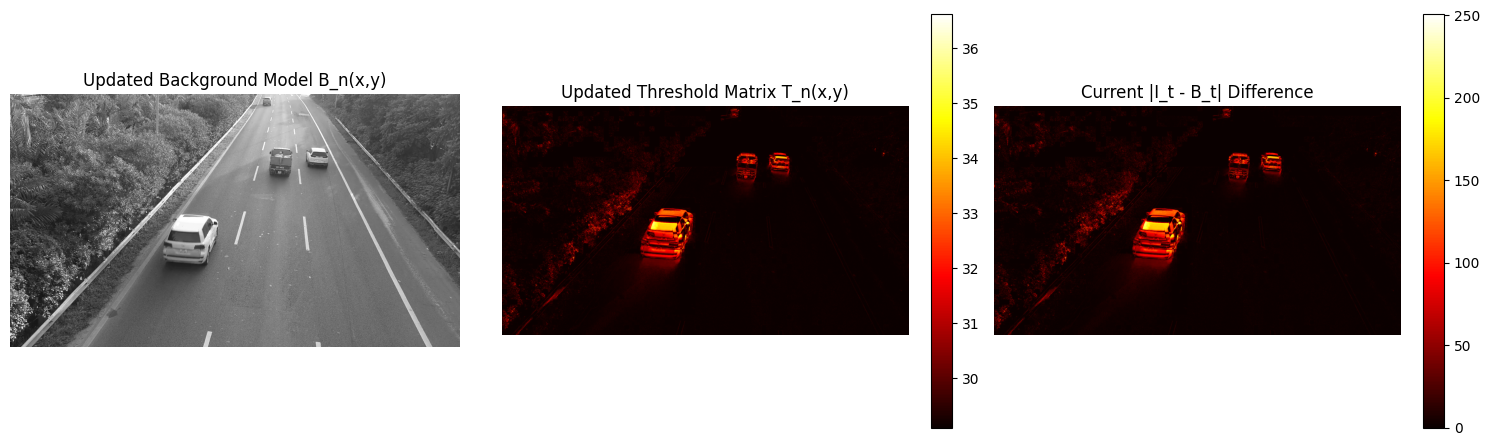

Threshold statistics after update:
  Min: 29.10
  Max: 36.63
  Mean: 29.25
  Std: 0.47


In [43]:
# Update the detector models
detector._update_models(curr, final_fg)

# Visualize updated models
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(detector.background, cmap='gray')
axes[0].set_title('Updated Background Model B_n(x,y)')
axes[0].axis('off')

im1 = axes[1].imshow(detector.threshold_matrix, cmap='hot')
axes[1].set_title('Updated Threshold Matrix T_n(x,y)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Show difference from original
diff = np.abs(curr - detector.background)
im2 = axes[2].imshow(diff, cmap='hot')
axes[2].set_title('Current |I_t - B_t| Difference')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

print(f"Threshold statistics after update:")
print(f"  Min: {detector.threshold_matrix.min():.2f}")
print(f"  Max: {detector.threshold_matrix.max():.2f}")
print(f"  Mean: {detector.threshold_matrix.mean():.2f}")
print(f"  Std: {detector.threshold_matrix.std():.2f}")

## Step 10: Process Multiple Frames and Show Results

In [44]:
# Reset video to beginning
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

# Reset detector
detector.reset()

# Process first 10 frames and store results
frames_to_process = 10
results = []

prev2_frame = None
prev_frame = None

for i in range(frames_to_process):
    ret, frame = cap.read()
    if not ret:
        break
    
    # Compute foreground mask
    fg_mask = detector.compute_foreground_mask(frame, prev_frame, prev2_frame)
    
    # Store result
    results.append({
        'frame': frame.copy(),
        'mask': fg_mask.copy(),
        'background': detector.background.copy(),
        'threshold_mean': detector.threshold_matrix.mean()
    })
    
    # Update frame history
    prev2_frame = prev_frame
    prev_frame = frame

print(f"✓ Processed {len(results)} frames")

✓ Processed 10 frames


## Step 11: Visualize Temporal Evolution

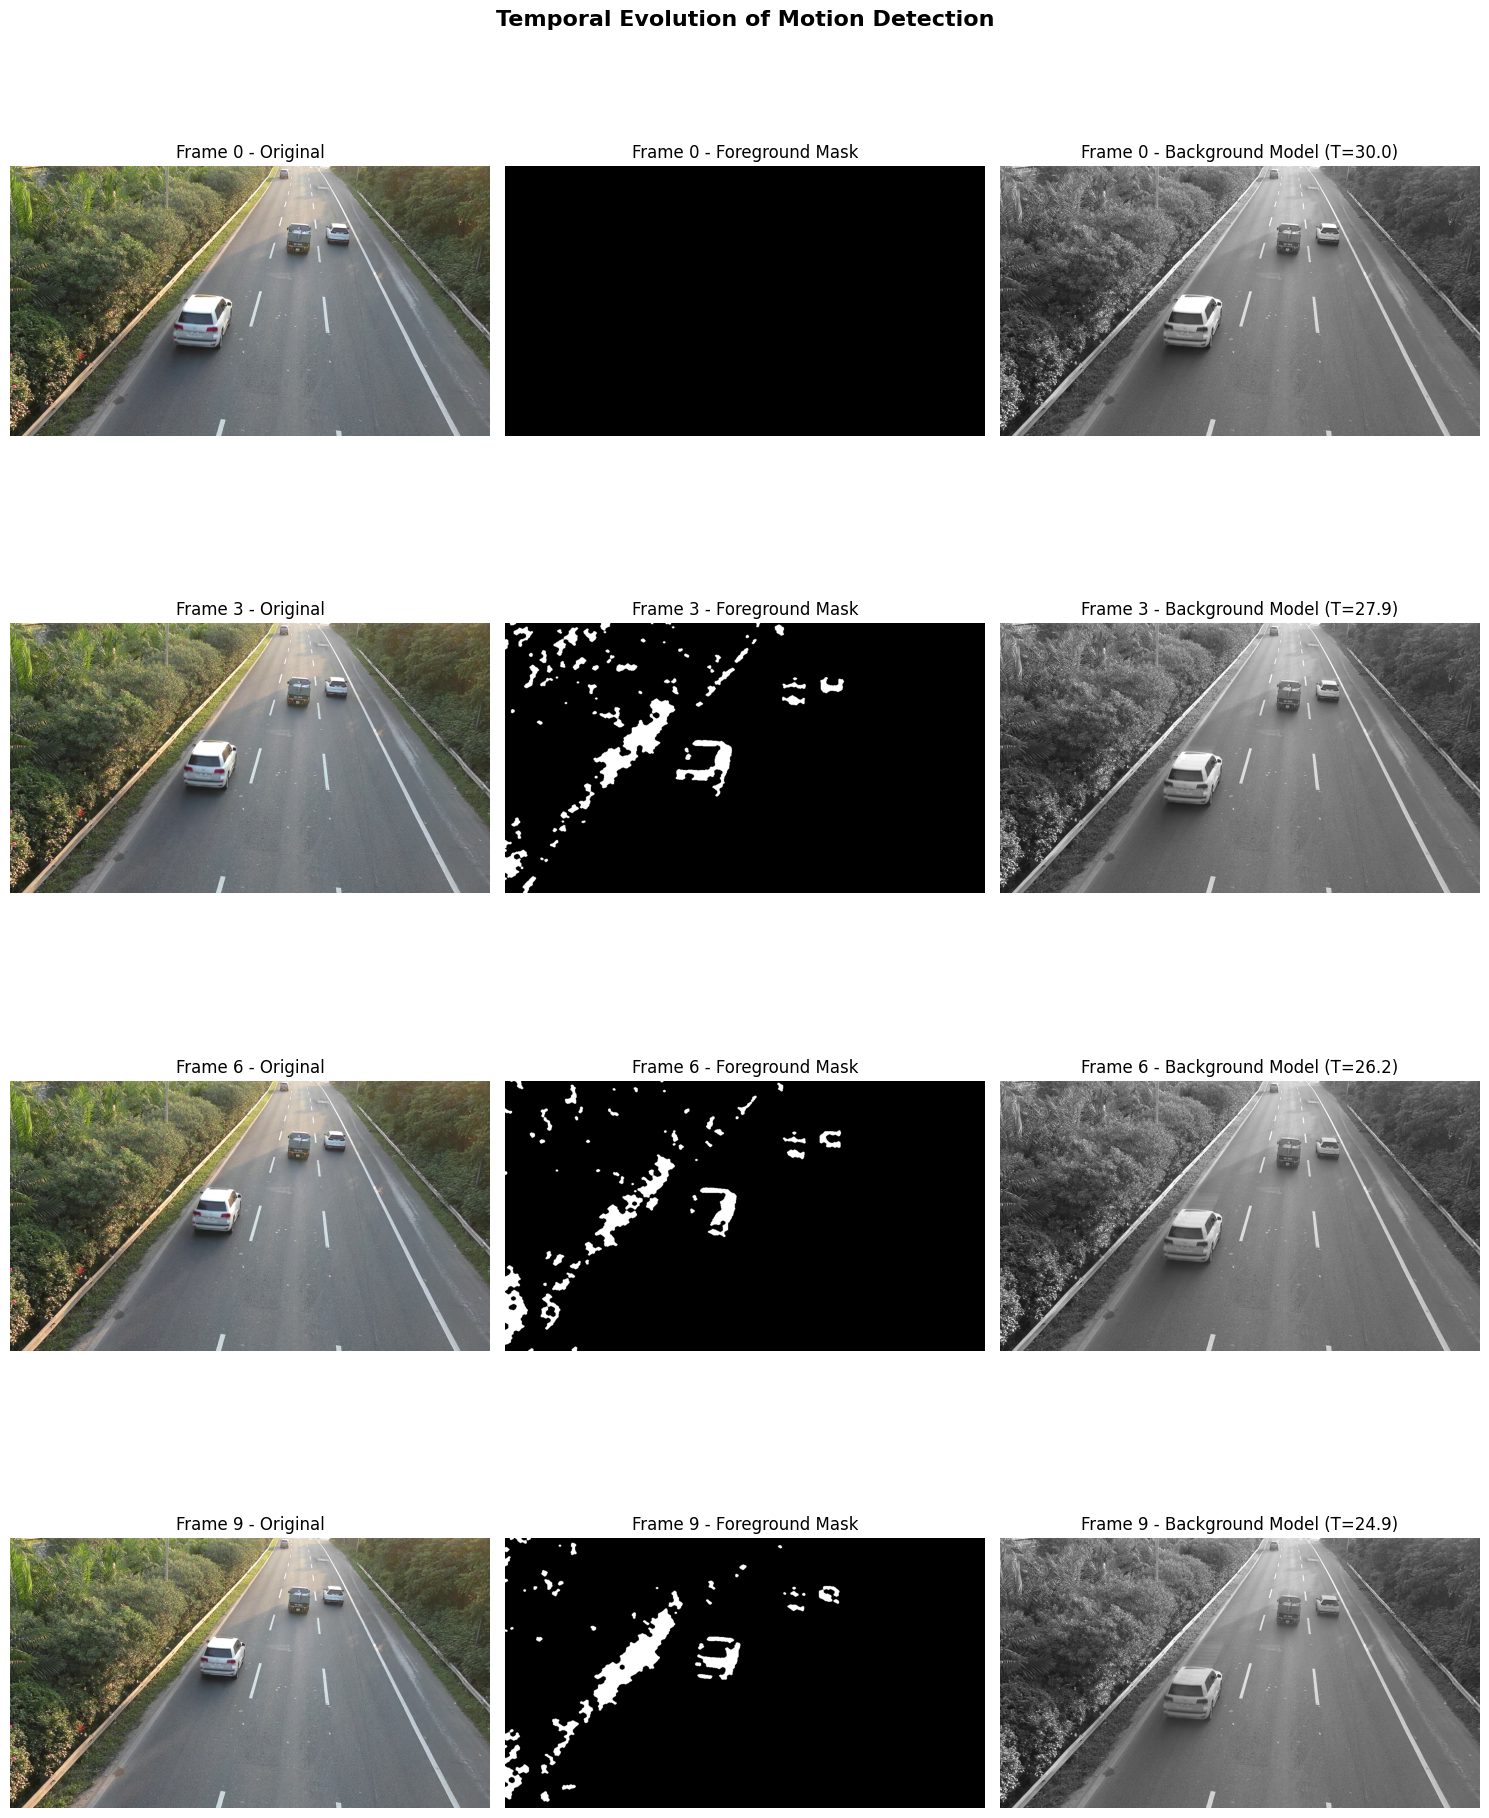

In [45]:
# Show results for selected frames
selected_frames = [0, 3, 6, 9]
fig, axes = plt.subplots(len(selected_frames), 3, figsize=(15, 5*len(selected_frames)))

for idx, frame_num in enumerate(selected_frames):
    if frame_num >= len(results):
        continue
    
    result = results[frame_num]
    
    # Original frame
    axes[idx, 0].imshow(cv2.cvtColor(result['frame'], cv2.COLOR_BGR2RGB))
    axes[idx, 0].set_title(f'Frame {frame_num} - Original')
    axes[idx, 0].axis('off')
    
    # Foreground mask
    axes[idx, 1].imshow(result['mask'], cmap='gray')
    axes[idx, 1].set_title(f'Frame {frame_num} - Foreground Mask')
    axes[idx, 1].axis('off')
    
    # Background model
    axes[idx, 2].imshow(result['background'], cmap='gray')
    axes[idx, 2].set_title(f'Frame {frame_num} - Background Model (T̄={result["threshold_mean"]:.1f})')
    axes[idx, 2].axis('off')

plt.suptitle('Temporal Evolution of Motion Detection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 12: Analyze Threshold Adaptation

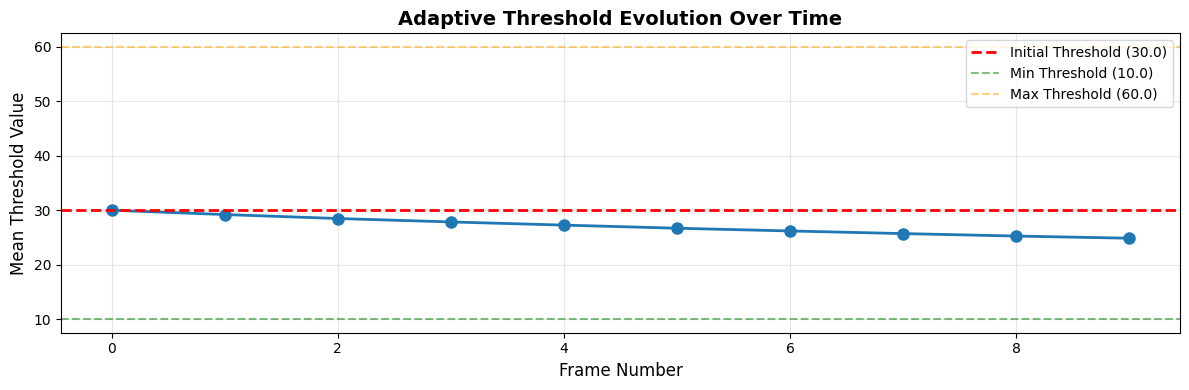


Threshold Statistics:
  Initial mean: 30.00
  Final mean: 24.86
  Change: -5.14


In [46]:
# Plot threshold evolution
threshold_means = [r['threshold_mean'] for r in results]

plt.figure(figsize=(12, 4))
plt.plot(threshold_means, marker='o', linewidth=2, markersize=8)
plt.axhline(y=motion_config.initial_threshold, color='r', linestyle='--', 
            label=f'Initial Threshold ({motion_config.initial_threshold})', linewidth=2)
plt.axhline(y=motion_config.min_threshold, color='g', linestyle='--', 
            label=f'Min Threshold ({motion_config.min_threshold})', alpha=0.5)
plt.axhline(y=motion_config.max_threshold, color='orange', linestyle='--', 
            label=f'Max Threshold ({motion_config.max_threshold})', alpha=0.5)
plt.xlabel('Frame Number', fontsize=12)
plt.ylabel('Mean Threshold Value', fontsize=12)
plt.title('Adaptive Threshold Evolution Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nThreshold Statistics:")
print(f"  Initial mean: {threshold_means[0]:.2f}")
print(f"  Final mean: {threshold_means[-1]:.2f}")
print(f"  Change: {threshold_means[-1] - threshold_means[0]:.2f}")

## Step 13: Overlay Foreground on Original

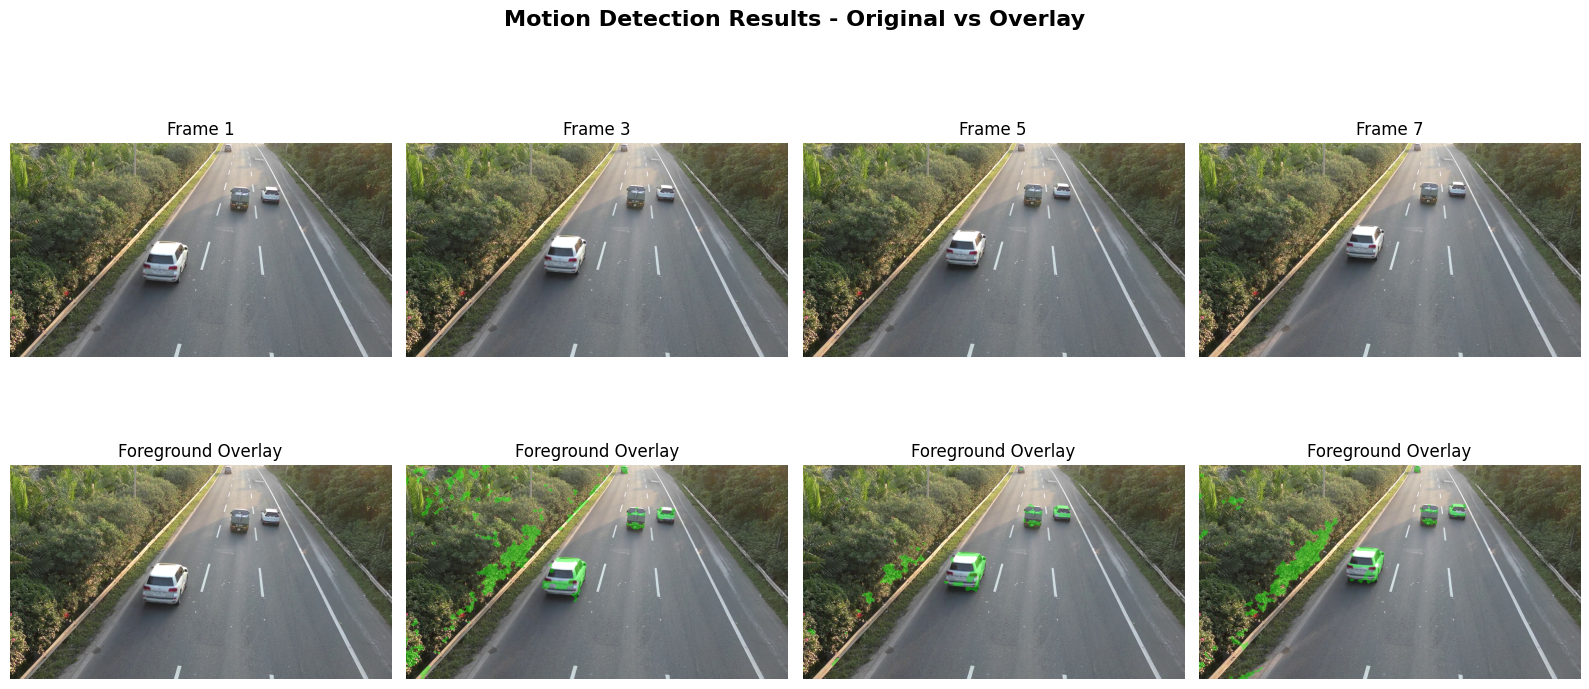

In [47]:
# Create overlay visualization for selected frames
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, frame_num in enumerate([1, 3, 5, 7]):
    if frame_num >= len(results):
        continue
    
    result = results[frame_num]
    frame = result['frame']
    mask = result['mask']
    
    # Original
    axes[0, idx].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    axes[0, idx].set_title(f'Frame {frame_num}')
    axes[0, idx].axis('off')
    
    # Overlay
    overlay = frame.copy()
    overlay[mask > 0] = [0, 255, 0]  # Green for foreground
    blended = cv2.addWeighted(frame, 0.6, overlay, 0.4, 0)
    
    axes[1, idx].imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
    axes[1, idx].set_title(f'Foreground Overlay')
    axes[1, idx].axis('off')

plt.suptitle('Motion Detection Results - Original vs Overlay', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 14: Cleanup

In [48]:
# Release video capture
cap.release()
print("✓ Video capture released")
print("✓ Demo complete!")

✓ Video capture released
✓ Demo complete!


## Summary

This notebook demonstrated the complete motion detection pipeline:

1. **Three-Frame Differencing**: Validates motion by comparing current frame with two previous frames
2. **Adaptive Background Model**: Maintains a running estimate of the static background scene
3. **Adaptive Threshold Matrix**: Adjusts detection sensitivity per-pixel based on observed variance
4. **Masked Background Subtraction**: Uses motion mask to constrain background subtraction
5. **Two-Frame Differencing**: Captures fast-moving objects with spatial support regions
6. **Shadow Removal**: Eliminates shadow false positives using intensity ratios
7. **Morphological Operations**: Cleans up noise and fills gaps in detected regions

The algorithm adapts over time, learning the background and adjusting thresholds to handle varying lighting conditions and scene changes.